# STEP 1 — EXTERNAL IMAGE PRODUCT PREDICTION

This notebook demonstrates the use of the trained ResNet-50 model for predicting supermarket product classes from external input images.

The trained Stage 2 fine-tuned model is loaded from the saved checkpoint. An input image is preprocessed using the same image transformation applied during model evaluation and then passed through the trained model.

### Objectives

- Load the trained ResNet-50 model
- Load the 81 supermarket product classes
- Load the saved Stage 2 checkpoint
- Upload or select an external product image
- Apply the required preprocessing
- Predict the product class
- Display the Top-1 prediction and confidence
- Display the Top-5 predictions
- Visualize the prediction result
- Save the prediction results

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)

Libraries imported successfully.
PyTorch version: 2.14.0+cpu


In [2]:
PROJECT_ROOT = os.path.abspath("..")

DATASET_ROOT = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "GroceryStoreDataset-master",
    "dataset"
)

CHECKPOINT_PATH = os.path.join(
    PROJECT_ROOT,
    "results",
    "checkpoints",
    "resnet50",
    "resnet50_stage2_best.pth"
)

CLASSES_CSV = os.path.join(
    DATASET_ROOT,
    "classes.csv"
)

print("Project root:")
print(PROJECT_ROOT)

print("\nCheckpoint exists:", os.path.exists(CHECKPOINT_PATH))
print("Classes file exists:", os.path.exists(CLASSES_CSV))

Project root:
c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification

Checkpoint exists: True
Classes file exists: True


In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Inference device:", device)

Inference device: cpu


Load the 81 class names

In [4]:
classes_df = pd.read_csv(CLASSES_CSV)

class_names = (
    classes_df
    .sort_values("Class ID (int)")["Class Name (str)"]
    .tolist()
)

num_classes = len(class_names)

print("Number of classes:", num_classes)
print("\nFirst 10 classes:")
print(class_names[:10])

Number of classes: 81

First 10 classes:
['Golden-Delicious', 'Granny-Smith', 'Pink-Lady', 'Red-Delicious', 'Royal-Gala', 'Avocado', 'Banana', 'Kiwi', 'Lemon', 'Lime']


Recreate ResNet-50 architecture

In [5]:
model = models.resnet50(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

print("ResNet-50 architecture created.")
print("Number of output classes:", num_classes)

ResNet-50 architecture created.
Number of output classes: 81


Load trained checkpoint

In [6]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

print("Checkpoint loaded successfully.")

print("\nCheckpoint information:")
print("Model:", checkpoint["model_name"])
print("Number of classes:", checkpoint["num_classes"])
print("Image size:", checkpoint["image_size"])
print("Best validation accuracy:",
      round(checkpoint["best_val_accuracy"] * 100, 2), "%")
print("Best validation loss:",
      round(checkpoint["best_val_loss"], 6))

Checkpoint loaded successfully.

Checkpoint information:
Model: ResNet-50
Number of classes: 81
Image size: 224
Best validation accuracy: 72.3 %
Best validation loss: 0.933781


Verify checkpoint

In [7]:
assert checkpoint["num_classes"] == num_classes
assert checkpoint["model_name"] == "ResNet-50"
assert checkpoint["image_size"] == 224

print("Checkpoint verification passed.")

Checkpoint verification passed.


Load trained weights

In [8]:
model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Trained Stage 2 model loaded successfully.")
print("Model is ready for external image prediction.")

Trained Stage 2 model loaded successfully.
Model is ready for external image prediction.


Define inference preprocessing

In [9]:
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Inference preprocessing defined.")

Inference preprocessing defined.


Create external image folder

In [10]:
EXTERNAL_IMAGE_DIR = os.path.join(
    PROJECT_ROOT,
    "external_images"
)

os.makedirs(
    EXTERNAL_IMAGE_DIR,
    exist_ok=True
)

print("External image directory:")
print(EXTERNAL_IMAGE_DIR)
print("\nDirectory exists:", os.path.exists(EXTERNAL_IMAGE_DIR))

External image directory:
c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\external_images

Directory exists: True


In [11]:
external_images = [
    file for file in os.listdir(EXTERNAL_IMAGE_DIR)
    if file.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    )
]

print("External images found:", len(external_images))

for i, filename in enumerate(external_images):
    print(f"{i}: {filename}")

External images found: 1
0: apple.webp


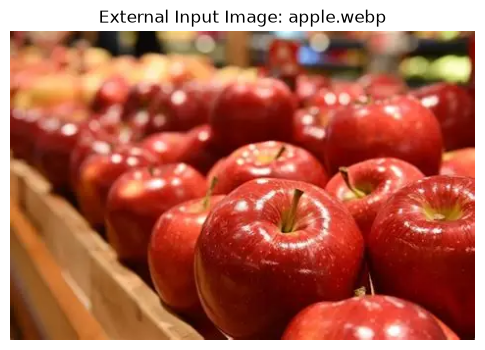

Image loaded successfully.
Image size: (474, 315)


In [12]:
image_filename = external_images[0]

image_path = os.path.join(
    EXTERNAL_IMAGE_DIR,
    image_filename
)

image = Image.open(
    image_path
).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"External Input Image: {image_filename}")
plt.show()

print("Image loaded successfully.")
print("Image size:", image.size)

Predict the external image

In [13]:
input_tensor = inference_transform(image)

input_batch = input_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_batch)

probabilities = torch.softmax(
    outputs,
    dim=1
)

predicted_class_id = torch.argmax(
    probabilities,
    dim=1
).item()

predicted_class_name = class_names[
    predicted_class_id
]

confidence = probabilities[
    0,
    predicted_class_id
].item()

print("=" * 60)
print("EXTERNAL IMAGE PREDICTION")
print("=" * 60)

print("Image:", image_filename)
print("Predicted product:", predicted_class_name)
print("Confidence:", round(confidence * 100, 2), "%")

print("=" * 60)

EXTERNAL IMAGE PREDICTION
Image: apple.webp
Predicted product: Red-Delicious
Confidence: 93.03 %


Generate Top-5 predictions

In [14]:
top5_probabilities, top5_indices = torch.topk(
    probabilities,
    k=5,
    dim=1
)

top5_results = []

for rank, (probability, class_id) in enumerate(
    zip(
        top5_probabilities[0],
        top5_indices[0]
    ),
    start=1
):
    class_id = class_id.item()
    probability = probability.item()

    top5_results.append({
        "Rank": rank,
        "Product": class_names[class_id],
        "Probability (%)": round(
            probability * 100,
            2
        )
    })

top5_df = pd.DataFrame(top5_results)

print("TOP-5 PREDICTIONS")
display(top5_df)

TOP-5 PREDICTIONS


,Rank,Product,Probability (%)
0,1,Red-Delicious,93.03
1,2,Vine-Tomato,1.99
2,3,Regular-Tomato,1.98
3,4,Beef-Tomato,0.94
4,5,Pink-Lady,0.58


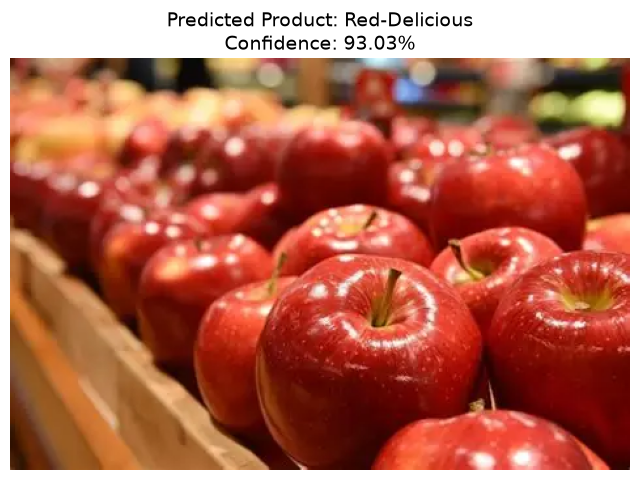

In [15]:
plt.figure(figsize=(8, 7))

plt.imshow(image)
plt.axis("off")

plt.title(
    f"Predicted Product: {predicted_class_name}\n"
    f"Confidence: {confidence * 100:.2f}%",
    fontsize=14
)

plt.show()

In [16]:
EXTERNAL_RESULTS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "external_image_prediction"
)

os.makedirs(
    EXTERNAL_RESULTS_DIR,
    exist_ok=True
)

prediction_result = {
    "image": image_filename,
    "model": "ResNet-50",
    "checkpoint": "resnet50_stage2_best.pth",
    "predicted_class": predicted_class_name,
    "confidence_percent": round(
        confidence * 100,
        2
    ),
    "top5_predictions": top5_results
}

result_json_path = os.path.join(
    EXTERNAL_RESULTS_DIR,
    "external_prediction_result.json"
)

with open(result_json_path, "w") as f:
    json.dump(
        prediction_result,
        f,
        indent=4
    )

print("Prediction result saved:")
print(result_json_path)

Prediction result saved:
c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\results\external_image_prediction\external_prediction_result.json


In [17]:
top5_csv_path = os.path.join(
    EXTERNAL_RESULTS_DIR,
    "external_prediction_top5.csv"
)

top5_df.to_csv(
    top5_csv_path,
    index=False
)

print("Top-5 prediction table saved:")
print(top5_csv_path)

Top-5 prediction table saved:
c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\results\external_image_prediction\external_prediction_top5.csv


## External Image Prediction — Summary

The trained ResNet-50 Stage 2 model was loaded from the saved checkpoint and evaluated on an external supermarket product image.

The input image was resized to 224 × 224 pixels and normalized using the same ImageNet normalization applied during model evaluation.

The model produced a Top-1 product prediction together with its confidence score. The Top-5 predictions were also generated to show alternative product classes considered by the model.

This experiment demonstrates the practical use of the trained model for image-based supermarket product identification.